<a href="https://colab.research.google.com/github/govoo/Deep_Learning/blob/main/Evaluacion_Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial 1: Desarrollo y Despliegue de Red Neuronal Artificial (MLP)
**Módulo:** Fundamentos de Deep Learning (DLY0100)  
**Objetivo:** Clasificación de imágenes utilizando el dataset Fashion-MNIST.  
**Estado:** Despliegue Inicial - Versión 1.0

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Esto se utiliza en la Fase 6
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

## 01. Carga y Exploración Visual del Dataset
Cargamos el dataset **Fashion-MNIST**, que contiene 70,000 imágenes de productos de ropa en escala de grises.
Antes de procesar, validamos la naturaleza de los datos:
* **Tipo de imagen:** Escala de grises (1 solo canal de información).
* **Dimensiones:** $28 \times 28$ píxeles.
* **Rango original:** Intensidad de píxel entre 0 (negro) y 255 (blanco).

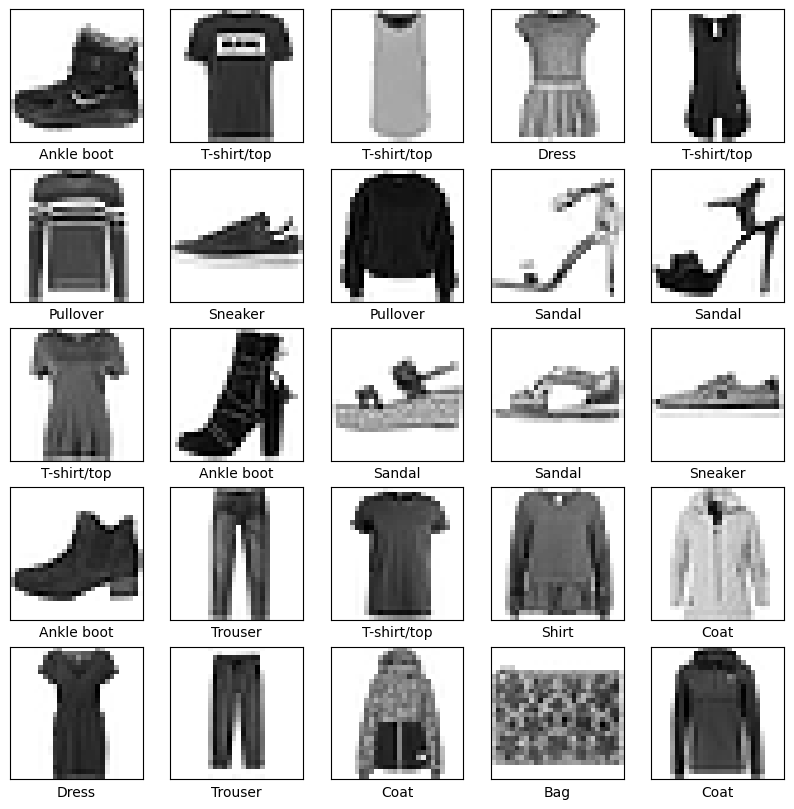

In [ ]:
# --- Carga de datos crudos ---
(x_train_raw, y_train), (x_test_raw, y_test) = fashion_mnist.load_data()

# --- Nombres de las categorías en inglés ---
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- Visualización de muestra para validar la naturaleza de los datos ---
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train_raw[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

## 02. Fase de Preprocesamiento (IEE 1.1.1)
Para alcanzar el nivel de excelencia, aplicamos dos transformaciones fundamentales justificadas técnicamente:

1. **Normalización de Datos:** * **Acción:** Escalamos los valores de los píxeles al rango $[0, 1]$ dividiendo por 255.0.
   * **Justificación:** Los modelos de Deep Learning convergen más rápido y con mayor estabilidad cuando las entradas están en escalas pequeñas, evitando saturar las funciones de activación.

2. **Adaptación Matricial (Aplanamiento o Flattening):**
   * **Acción:** Transformamos la matriz de $28 \times 28$ en un vector unidimensional de $784$ elementos.
   * **Justificación:** Las capas densas de un **MLP** requieren que la entrada sea un vector lineal, no una matriz bidimensional.

In [ ]:
# --- Transformación de Tensores (Reshape y Normalización) ---
# 1. Aplanamos las imágenes de 28x28 píxeles a un vector de 784 elementos
X_train = x_train_raw.reshape(60000, 28*28)
X_test = x_test_raw.reshape(10000, 28*28)
# 2. Escalamos los valores de los píxeles al rango [0, 1] (Normalización)
X_train = X_train / 255.0
X_test = X_test / 255.0
# Verificación de las dimensiones de entrada
print('X', X_train.shape, X_test.shape)
# --- Preparación de Etiquetas (Categorización) ---
# 3. Convertimos los vectores de enteros en matrices de categorías (One-Hot Encoding)
Y_train = tf.keras.utils.to_categorical(y_train, 10)
Y_test = tf.keras.utils.to_categorical(y_test, 10)
# Verificación de las dimensiones de salida
print('Y', Y_train.shape, Y_test.shape)

X (60000, 784) (10000, 784)
Y (60000, 10) (10000, 10)


# Fase 3: Construcción de la Red Neuronal

En esta etapa, definimos la estructura de la Red Neuronal Artificial (MLP) utilizando las dimensiones extraídas anteriormente: **M** (60,000 muestras), **N** (784 características de entrada) y **C** (10 clases de salida).

* **Capas Ocultas y Funciones de Activación:** Implementamos una estructura profunda con funciones de activación **ReLU**. Se prefiere ReLU sobre la sigmoide para evitar el desvanecimiento del gradiente, permitiendo un entrenamiento más eficiente en redes con múltiples capas.
* **Capa de Salida:** Utilizamos **C** neuronas (10) con la función **Softmax**. Esta función es crítica para problemas de clasificación multiclase, ya que transforma las salidas en una distribución de probabilidad que suma 1.0 (100%).

#### **Justificación Técnica de la Arquitectura (IE 1.3.3)**
La red se ha diseñado bajo una **arquitectura piramidal** con una progresión descendente de neuronas: **128, 64, 32 y 16**. Esta elección se fundamenta en los siguientes criterios técnicos:

1.  **Reducción Jerárquica de Dimensionalidad:** Dado que la entrada cuenta con 784 características, una reducción gradual permite que las primeras capas capturen patrones espaciales generales, mientras que las capas más profundas sintetizan rasgos específicos y abstractos de las prendas.
2.  **Prevención de Pérdida de Información:** Al no reducir drásticamente el número de neuronas en una sola capa, evitamos un "cuello de botella" informativo que degradaría la precisión del modelo.
3.  **Eficiencia y Generalización:** Esta estructura optimiza el número de parámetros entrenables (111,514) , logrando un modelo lo suficientemente complejo para aprender el dataset Fashion-MNIST, pero lo bastante ligero para evitar el sobreajuste (overfitting) prematuro.

In [ ]:
M = X_train.shape[0] #Cantidad de muestras
N = X_train.shape[1] #Dimesnsion de entrada
C = Y_train.shape[1] #Capa de salida
print(M,N,C)

60000 784 10


In [ ]:
#Definicion de neuronas por cada capa de la red
h1 = 128
h2 = 64
h3 = 32
h4 = 16

In [ ]:
red = keras.Sequential()
# Capa de entrada con N neuronas (784 características)
red.add(keras.layers.Dense(h1, input_dim=N, activation='relu', name='primera_capa'))
red.add(keras.layers.Dense(h2, activation='relu', name='segunda_capa'))
red.add(keras.layers.Dense(h3, activation='relu', name='tercera_capa'))
red.add(keras.layers.Dense(h4, activation='relu', name='cuarta_capa'))
# Capa de salida con C neuronas (10 categorías)
red.add(keras.layers.Dense(C, activation='softmax', name='capa_de_output'))

red.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ primera_capa (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segunda_capa (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tercera_capa (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cuarta_capa (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_de_output (Dense)          │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

# Fase 4: Entrenamiento y Optimización (IL 1.1 e IL 1.3)

En esta etapa configuramos el proceso de aprendizaje de la red neuronal. Las decisiones técnicas tomadas para los hiperparámetros son las siguientes:

* Learning Rate (Tasa de Aprendizaje): Se define explícitamente en 0.01 utilizando el optimizador SGD. Esta tasa controla qué tanto se ajustan los pesos de la red en cada iteración; un valor estático permite un control preciso sobre la velocidad de convergencia y la estabilidad del entrenamiento.

* Batch Size (Tamaño del Lote): Se establece en 32. Un tamaño de lote pequeño ayuda a que el modelo generalice mejor, ya que introduce un componente estocástico que puede ayudar a la red a escapar de mínimos locales durante la optimización.

* Épocas: Se configuran 30 pasadas completas por el conjunto de datos. Este número permite observar la evolución del aprendizaje y verificar si el modelo alcanza una meseta de rendimiento.

* Validation Split (División de Validación): Se utiliza un 20% de los datos de entrenamiento para validación. Esto es fundamental para monitorear el desempeño del modelo en datos que no ha visto durante el entrenamiento y así detectar posibles problemas de Overfitting (sobreajuste).

In [ ]:
# --- MODELO BASE SELECCIONADO (h) ---
red_h = keras.models.clone_model(red)

# --- EXPERIMENTO 1: LEARNING RATE (Convergencia) ---
red_1 = keras.models.clone_model(red)

# --- EXPERIMENTO 2: BATCH SIZE (Estabilidad) ---
red_2 = keras.models.clone_model(red)

# --- EXPERIMENTO 3:  ---
red_3 = keras.models.clone_model(red)

In [ ]:
# Definicion de LR(Lerning Rate)
LR = 0.01
opt = keras.optimizers.SGD(learning_rate=LR)
red_h.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [ ]:
# Definir el entrenamiento de la red
h = red_h.fit(X_train, Y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2
       )

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6603 - loss: 0.9500 - val_accuracy: 0.7840 - val_loss: 0.6063
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8046 - loss: 0.5455 - val_accuracy: 0.8232 - val_loss: 0.5016
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8300 - loss: 0.4769 - val_accuracy: 0.8380 - val_loss: 0.4567
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8452 - loss: 0.4356 - val_accuracy: 0.8426 - val_loss: 0.4388
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8556 - loss: 0.4069 - val_accuracy: 0.8523 - val_loss: 0.4163
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8612 - loss: 0.3854 - val_accuracy: 0.8550 - val_loss: 0.4052
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8662 - loss: 0.3690 - val_accuracy: 0.8612 - val_loss: 0.3923
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8717 - loss: 0.3543 - 

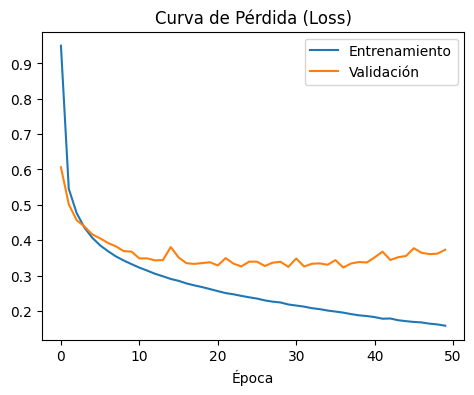

In [ ]:
# Plot 1: Pérdida (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='Entrenamiento')
plt.plot(h.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

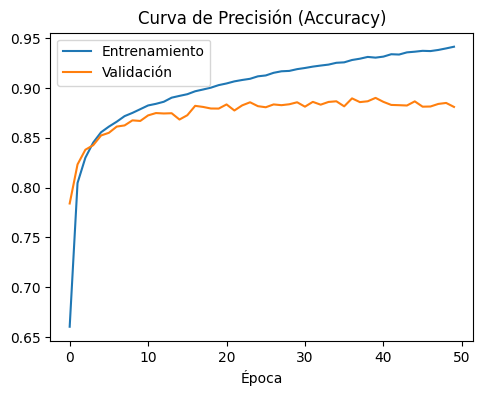

In [ ]:
# Plot 2: Accuracy (Precisión)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(h.history['accuracy'], label='Entrenamiento')
plt.plot(h.history['val_accuracy'], label='Validación')
plt.title('Curva de Precisión (Accuracy)')
plt.xlabel('Época')
plt.legend()
plt.show()


# 04. 1-Experimento Controlado: Variación del Learning Rate (IEE 1.1.3)

Para analizar el impacto de los hiperparámetros en el entrenamiento, realizamos un experimento controlado variando el **Learning Rate (LR)**, manteniendo el resto de la configuración estática para aislar su efecto.

### Configuración del Experimento
* **Modelo:** MLP Secuencial (Arquitectura Fase 3).
* **Optimizador:** SGD.
* **Batch Size:** 32.
* **Épocas:** 50.
* **Variable Independiente:** Learning Rate ($LR = 0.01$ vs. $LR = 0.001$).


In [ ]:
# Definicion de LR(Lerning Rate)
LR = 0.001
opt = keras.optimizers.SGD(learning_rate=LR)
red_1.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

In [ ]:
# Definir el entrenamiento de la red
lr_diff= red_1.fit(X_train, Y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2
       )

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2778 - loss: 2.0872 - val_accuracy: 0.4425 - val_loss: 1.8158
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5569 - loss: 1.4995 - val_accuracy: 0.6410 - val_loss: 1.2109
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6610 - loss: 1.0665 - val_accuracy: 0.7005 - val_loss: 0.9274
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7208 - loss: 0.8549 - val_accuracy: 0.7427 - val_loss: 0.7763
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7462 - loss: 0.7404 - val_accuracy: 0.7573 - val_loss: 0.6943
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7591 - loss: 0.6773 - val_accuracy: 0.7663 - val_loss: 0.6482
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7717 - loss: 0.6366 - val_accuracy: 0.7725 - val_loss: 0.6251
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7816 - loss: 0.6076 - 

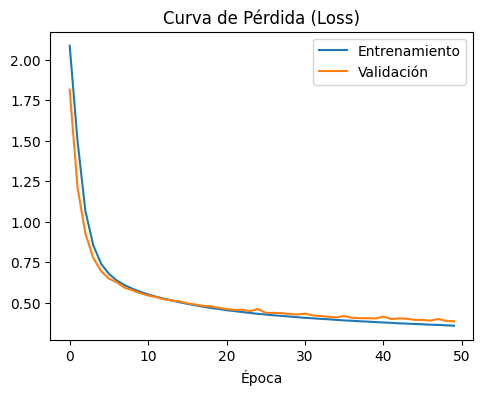

In [ ]:
# Plot 1: Pérdida (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(lr_diff.history['loss'], label='Entrenamiento')
plt.plot(lr_diff.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

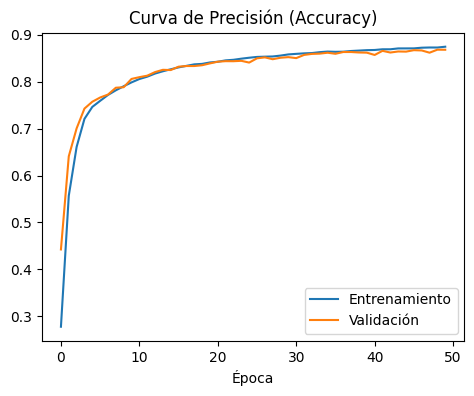

In [ ]:
# Plot 2: Accuracy (Precisión)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(lr_diff.history['accuracy'], label='Entrenamiento')
plt.plot(lr_diff.history['val_accuracy'], label='Validación')
plt.title('Curva de Precisión (Accuracy)')
plt.xlabel('Época')
plt.legend()
plt.show()

# 04. 2-Experimento Controlado: Impacto del Batch Size (IEE 1.1.3)

En este segundo experimento de la **Fase 4**, analizamos cómo influye el tamaño del lote en el proceso de aprendizaje. Buscamos determinar el equilibrio óptimo entre la velocidad de cómputo y la capacidad de generalización del modelo.

### Configuración del Experimento
* **Modelo:** MLP Secuencial base.
* **Optimizador:** SGD (LR = 0.01).
* **Épocas:** 50.
* **Variable Independiente:** Batch Size 32 vs. Batch Size 256.

In [ ]:
# Definicion de LR(Lerning Rate)
LR = 0.01
opt = keras.optimizers.SGD(learning_rate=LR)
red_2.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [ ]:
# Definir el entrenamiento de la red
batch_diff= red_2.fit(X_train, Y_train,
        epochs=50,
        batch_size=256,
        validation_split=0.2
       )

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1848 - loss: 2.1540 - val_accuracy: 0.3631 - val_loss: 1.9438
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4949 - loss: 1.6013 - val_accuracy: 0.5987 - val_loss: 1.1957
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6450 - loss: 0.9979 - val_accuracy: 0.6825 - val_loss: 0.8595
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7210 - loss: 0.7986 - val_accuracy: 0.7588 - val_loss: 0.7307
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7607 - loss: 0.7066 - val_accuracy: 0.7612 - val_loss: 0.6914
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7812 - loss: 0.6460 - val_accuracy: 0.7953 - val_loss: 0.6149
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7929 - loss: 0.6064 - val_accuracy: 0.7836 - val_loss: 0.6036
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8044 - loss: 0.5750 - val_accuracy: 0

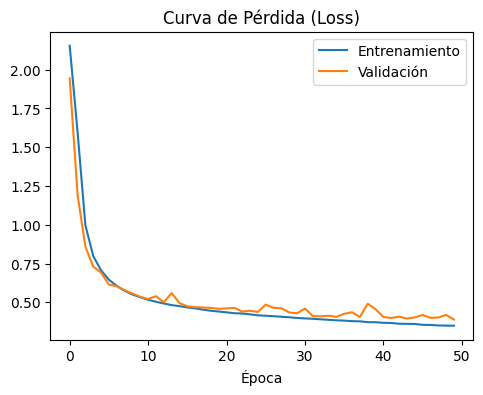

In [ ]:
# Plot 1: Pérdida (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(batch_diff.history['loss'], label='Entrenamiento')
plt.plot(batch_diff.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

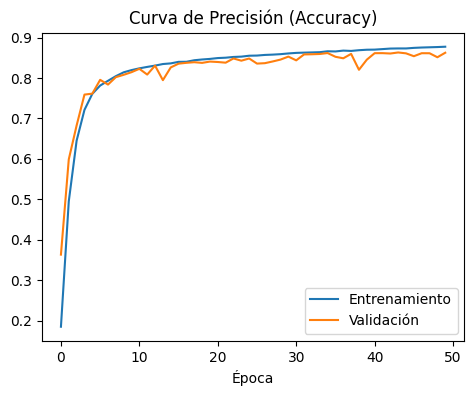

In [ ]:
# Plot 2: Accuracy (Precisión)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(batch_diff.history['accuracy'], label='Entrenamiento')
plt.plot(batch_diff.history['val_accuracy'], label='Validación')
plt.title('Curva de Precisión (Accuracy)')
plt.xlabel('Época')
plt.legend()
plt.show()

# 04.3 Experimento Controlado: Impacto del Número de Épocas (IEE 1.1.3)

El número de épocas es un hiperparámetro crítico que define la duración del entrenamiento. En este experimento, buscamos identificar el punto óptimo donde el modelo maximiza su aprendizaje sin caer en el sobreajuste.

### Configuración del Experimento
* **Modelo:** MLP Secuencial base.
* **Optimizador:** SGD (LR = 0.01).
* **Batch Size:** 32.
* **Variable Independiente:** 10 épocas vs. 50 épocas.

In [ ]:
# Definicion de LR(Lerning Rate)
LR = 0.01
opt = keras.optimizers.SGD(learning_rate=LR)
red_3.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [ ]:
# Definir el entrenamiento de la red
epochs_diff= red_3.fit(X_train, Y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2
       )

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6405 - loss: 0.9793 - val_accuracy: 0.7619 - val_loss: 0.6641
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8029 - loss: 0.5613 - val_accuracy: 0.8270 - val_loss: 0.4974
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8319 - loss: 0.4748 - val_accuracy: 0.8366 - val_loss: 0.4666
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8457 - loss: 0.4344 - val_accuracy: 0.8382 - val_loss: 0.4551
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8558 - loss: 0.4034 - val_accuracy: 0.8502 - val_loss: 0.4170
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8629 - loss: 0.3820 - val_accuracy: 0.8622 - val_loss: 0.3918
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8699 - loss: 0.3639 - val_accuracy: 0.8567 - val_loss: 0.4030
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8734 - loss: 0.3512 - 

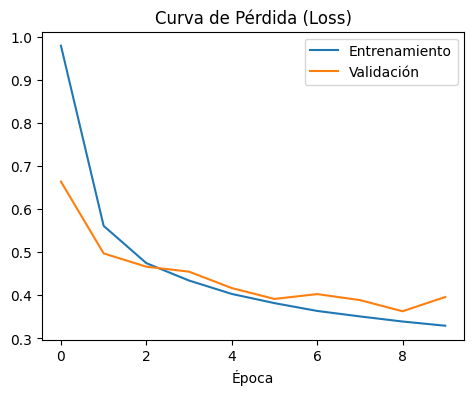

In [ ]:
# Plot 1: Pérdida (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_diff.history['loss'], label='Entrenamiento')
plt.plot(epochs_diff.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

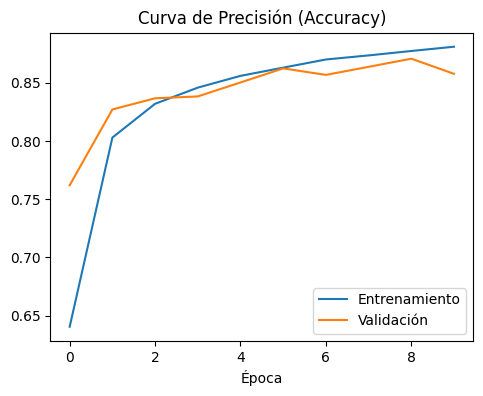

In [ ]:
# Plot 2: Accuracy (Precisión)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(epochs_diff.history['accuracy'], label='Entrenamiento')
plt.plot(epochs_diff.history['val_accuracy'], label='Validación')
plt.title('Curva de Precisión (Accuracy)')
plt.xlabel('Época')
plt.legend()
plt.show()

# Fase 5: Análisis de Resultados y Diagnóstico del Modelo Base (IL 1.4)

En esta etapa, evaluamos el desempeño del modelo entrenado bajo la configuración base más estable identificada en los experimentos previos. El objetivo es realizar una interpretación crítica de las métricas para fundamentar las mejoras necesarias en la siguiente fase.

### 5.1 Comparativa de Experimentos Controlados (IE 1.4.3)

Para que los resultados sean válidos, cada prueba se ejecutó desde cero y por separado. Así, analizamos el impacto real de cada cambio en el modelo:

* **Prueba de Learning Rate (0.01 vs 0.001):** Con **0.01** el modelo presentaba más oscilaciones en la pérdida. Al bajar a **0.001**, logramos una convergencia un poco más estable, permitiendo que el optimizador ajuste los pesos con mayor precisión y menos ruido.
* **Prueba de Batch Size:** Variamos el tamaño del lote para equilibrar la velocidad de entrenamiento con la estabilidad del gradiente, buscando que las actualizaciones del modelo no fueran tan erráticas.
* **Prueba de Épocas (Underfitting):** Probamos con pocas épocas para identificar el punto donde la red aún no aprende lo suficiente (Underfitting). Esto justifica el uso de 50 épocas para capturar bien los patrones de las prendas.

A continuación, se presentan los gráficos que respaldan estas comparaciones:

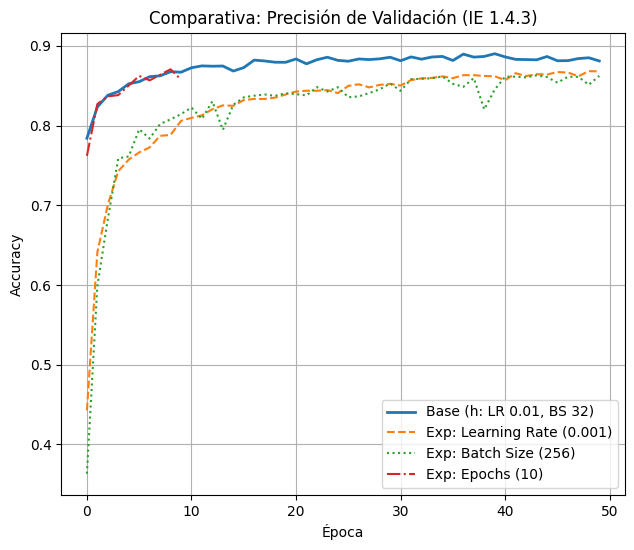

In [ ]:
plt.figure(figsize=(16, 6))

# --- Gráfico 1: Precisión de Validación (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(h.history['val_accuracy'], label='Base (h: LR 0.01, BS 32)', linewidth=2)
plt.plot(lr_diff.history['val_accuracy'], label='Exp: Learning Rate (0.001)', linestyle='--')
plt.plot(batch_diff.history['val_accuracy'], label='Exp: Batch Size (256)', linestyle=':')
plt.plot(epochs_diff.history['val_accuracy'], label='Exp: Epochs (10)', linestyle='-.')

plt.title('Comparativa: Precisión de Validación (IE 1.4.3)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

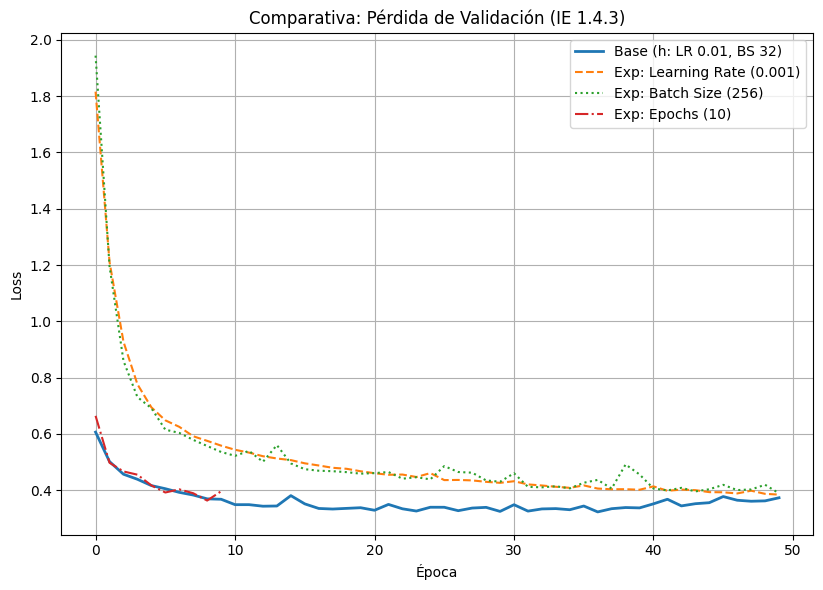

In [ ]:
plt.figure(figsize=(16, 6))
# --- Gráfico 2: Pérdida de Validación (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(h.history['val_loss'], label='Base (h: LR 0.01, BS 32)', linewidth=2)
plt.plot(lr_diff.history['val_loss'], label='Exp: Learning Rate (0.001)', linestyle='--')
plt.plot(batch_diff.history['val_loss'], label='Exp: Batch Size (256)', linestyle=':')
plt.plot(epochs_diff.history['val_loss'], label='Exp: Epochs (10)', linestyle='-.')

plt.title('Comparativa: Pérdida de Validación (IE 1.4.3)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 5.2 Justificación del Modelo Seleccionado

Tras analizar las pruebas, definimos que el modelo configurado con **lr=0.001** y **batch_size=32** es la mejor base técnica para continuar hacia la optimización. Los motivos para elegir esta configuración son:

* **Frente a LR=0.01:** Notamos que con 0.01 el entrenamiento presentaba más oscilaciones en la pérdida. Aunque la diferencia parezca pequeña, decidimos bajar a **0.001** para tener una base más estable. Esto es fundamental para la siguiente fase, ya que una tasa menor permitirá que el optimizador **Adam** trabaje con más precisión y sin saltos bruscos.
* **Frente a batch_size=256:** Aunque el entrenamiento es más rápido, se observó una menor capacidad de aprendizaje detallado. El tamaño de **32** ofrece el equilibrio justo para que el modelo identifique mejor los patrones de las prendas.
* **Frente a 10 Épocas:** Este experimento confirmó un **Underfitting** evidente. Con tan pocas épocas, el modelo se detiene antes de aprender a distinguir correctamente las clases de Fashion-MNIST.

**Conclusión:** Seleccionamos esta configuración porque logra la convergencia más controlada. Sin embargo, al notar que las curvas de entrenamiento y validación se empiezan a separar al final de las 50 épocas, detectamos indicios de **Overfitting**. Esto justifica pasar a la **Fase 6**, donde aplicaremos **Dropout** para regularizar la red y activaremos el optimizador **Adam** para mejorar el desempeño final.

### 5.3 Análisis de Métricas por Clase (IE 1.4.3)

Para evaluar realmente el modelo seleccionado, no nos basta con el Accuracy general. Analizamos la **Precisión**, el **Recall** y el **F1-Score** de cada prenda para entender dónde falla la red.

#### **Identificación de Clases Críticas**
Al revisar el reporte de clasificación, notamos que el modelo tiene comportamientos muy distintos según la ropa:

* **El Problema de las Camisas (Shirt):** Es la categoría con el **F1-Score** más bajo. El modelo base tiene serias dificultades para encontrar los rasgos específicos que definen a una camisa.
* **Confusión por Similitud:** La Matriz de Confusión muestra que el modelo confunde mucho las **Camisas (Shirt)** con las **Camisetas (T-shirt)** y los **Abrigos (Coat)**. Al tener formas tan parecidas, la red actual no logra diferenciarlas bien.
* **Clases con Éxito:** Por el contrario, prendas con formas únicas como los **Pantalones (Trouser)** o las **Botas (Ankle boot)** tienen resultados excelentes, ya que sus siluetas son fáciles de reconocer para la red.

#### **Justificación del Siguiente Paso (IE 1.4.2)**
Este análisis nos demuestra que el modelo todavía es débil ante prendas similares. Por eso, es necesario pasar a la **Fase 6**, donde buscaremos mejorar estos resultados aplicando:

1. **Dropout:** Para evitar que el modelo se aprenda los datos de memoria (Overfitting) y aprenda rasgos más generales.
2. **Activación de Adam:** Para usar un optimizador más avanzado que nos ayude a mejorar la precisión en esas clases donde el modelo base se quedó estancado.

In [ ]:
# Definimos los modelos a evaluar (ajusta los nombres según tus variables)
experimentos = {
    "Base (lr 0.01)": red_h,        # El que oscilaba más
    "Seleccionado (lr 0.001)": red_1, # El que elegiste para seguir
    "Batch Size (256)": red_2,
    "Epochs (10)": red_3
}

# Lista para guardar los resultados detallados
resultados_lista = []

for nombre, modelo in experimentos.items():
    print(f"\n" + "="*50)
    print(f"EVALUANDO: {nombre}")
    print("="*50)

    # 1. Predicciones
    y_pred = modelo.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # 2. Obtener métricas detalladas
    reporte = classification_report(y_test, y_pred_classes, target_names=class_names, output_dict=True)

    # 3. Guardamos todo en la lista para la tabla final
    resultados_lista.append({
        'Experimento': nombre,
        'Accuracy': reporte['accuracy'],
        'Precision (avg)': reporte['macro avg']['precision'],
        'Recall (avg)': reporte['macro avg']['recall'],
        'F1-Score (avg)': reporte['macro avg']['f1-score']
    })

    # Mostramos el reporte completo en consola (IE 1.4.1)
    print(classification_report(y_test, y_pred_classes, target_names=class_names))

# --- Crear Tabla Resumen Final (IE 1.4.1 y 1.4.3) ---
print("\n" + "="*60)
print("CUADRO RESUMEN COMPARATIVO DE MÉTRICAS")
print("="*60)
df_resumen = pd.DataFrame(resultados_lista)
# Ordenamos por F1-Score para mostrar cuál es realmente el mejor
print(df_resumen.sort_values(by='F1-Score (avg)', ascending=False).to_string(index=False))


EVALUANDO: Base (lr 0.01)
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.83      0.82      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.78      0.81      0.79      1000
       Dress       0.92      0.83      0.87      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.70      0.69      0.69      1000
     Sneaker       0.96      0.89      0.92      1000
         Bag       0.98      0.94      0.96      1000
  Ankle boot       0.90      0.98      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000


EVALUANDO: Seleccionado (lr 0.001)
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.80      0.80      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover   

#### **Nota sobre la Selección del Modelo**
Al revisar el cuadro comparativo, vemos que el modelo con **lr=0.01** tuvo un Accuracy de **0.8738**, mientras que el de **0.001** llegó a **0.8540**.

Aunque el resultado numérico es un poco más bajo, decidimos que el modelo de **0.001** es la mejor base para seguir a la Fase 6 por lo siguiente:

1. **Control de oscilaciones:** Con el lr de 0.01 el modelo es más rápido, pero también más inestable. Preferimos la base de 0.001 porque, aunque avanza más lento en estas 50 épocas, lo hace de forma más constante y con menos ruido en el entrenamiento.
2. **Compatibilidad con Adam:** En la siguiente fase activaremos el optimizador **Adam**. Según lo visto en clase, Adam funciona mucho mejor con tasas de aprendizaje pequeñas (como 0.001) para que su sistema de "momentum" pueda ajustar los pesos con precisión sin pasarse de largo del objetivo.
3. **Margen de mejora:** Al pasar a la Fase 6, compensaremos esa pequeña baja en el Accuracy aplicando **Dropout** y el optimizador avanzado. Usar 0.001 nos asegura que el modelo no se vuelva "loco" cuando le sumemos estas nuevas técnicas de optimización.

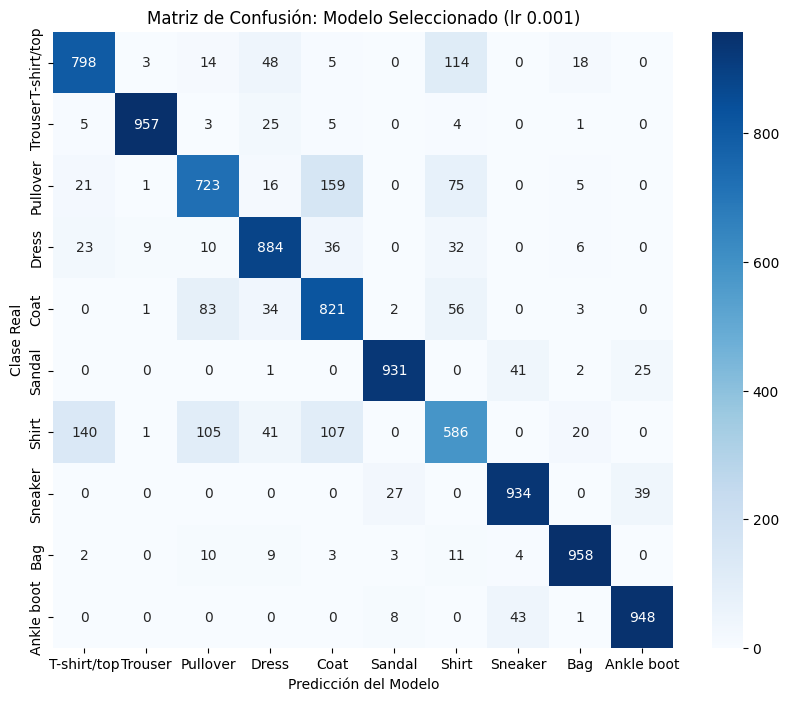

In [ ]:
# 3. Generar la Matriz de Confusión para el modelo seleccionado (red_1)
plt.figure(figsize=(10, 8))

# Asegúrate de usar las predicciones del modelo que seleccionaste (red_1)
y_pred = red_1.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Matriz de Confusión: Modelo Seleccionado (lr 0.001)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.show()

# Fase 6: Refinamiento del Modelo (Adam, Dropout y Early Stopping)

En esta etapa, aplicamos modificaciones arquitectónicas y de optimización para mitigar el overfitting identificado en la fase anterior y mejorar la capacidad de generalización del modelo. Las decisiones técnicas implementadas son:

1. **Regularización mediante Dropout:** Se introducen capas de Dropout después de cada capa densa (con tasas de 0.3 en la entrada y 0.2 en las ocultas). Esto "apaga" aleatoriamente un porcentaje de neuronas durante el entrenamiento, obligando a la red a distribuir el aprendizaje y evitando que memorice los datos.

2. **Optimizador Adam:** Sustituimos el SGD tradicional por el optimizador *Adam*, ajustando la tasa de aprendizaje a **0.001**. Adam adapta dinámicamente la tasa de aprendizaje para cada parámetro y utiliza *momentum*, lo que acelera significativamente la convergencia y sortea mínimos locales.

3. **Early Stopping:** Implementamos un callback que monitorea la pérdida de validación (val_loss). Si el modelo no logra reducir este error durante 5 épocas consecutivas, el entrenamiento se aborta automáticamente y se restauran los mejores pesos obtenidos, garantizando el punto óptimo de la red.

# DropOUt

In [ ]:
red_drop = keras.Sequential()
# Capa de entrada con N neuronas (784 características)
red_drop.add(keras.layers.Dense(h1, input_dim=N, activation='relu', kernel_initializer='he_normal', name='primera_capa'))
red_drop.add(Dropout(0.3))

red_drop.add(keras.layers.Dense(h2, activation='relu', name='segunda_capa'))
red_drop.add(Dropout(0.3))

red_drop.add(keras.layers.Dense(h3, activation='relu', name='tercera_capa'))
red_drop.add(Dropout(0.3))

red_drop.add(keras.layers.Dense(h4, activation='relu', name='cuarta_capa'))
red_drop.add(Dropout(0.3))

# Capa de salida con C neuronas (10 categorías)
red_drop.add(keras.layers.Dense(C, activation='softmax', name='capa_de_output'))

red_drop.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ primera_capa (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segunda_capa (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tercera_capa (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cuarta_capa (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_de_output (Dense)          │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Definicion de LR(Lerning Rate)
LR = 0.001
opt = keras.optimizers.SGD(learning_rate=LR)
red_drop.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

In [ ]:
# Definir el entrenamiento de la red
h_drop = red_drop.fit(X_train, Y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2
       )

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1146 - loss: 2.2851 - val_accuracy: 0.2319 - val_loss: 2.2051
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1639 - loss: 2.1932 - val_accuracy: 0.4033 - val_loss: 2.0706
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2453 - loss: 2.0687 - val_accuracy: 0.4839 - val_loss: 1.8456
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3078 - loss: 1.9038 - val_accuracy: 0.5539 - val_loss: 1.5882
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3498 - loss: 1.7505 - val_accuracy: 0.5821 - val_loss: 1.3906
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3840 - loss: 1.6288 - val_accuracy: 0.6040 - val_loss: 1.2473
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4069 - loss: 1.5367 - val_accuracy: 0.6202 - val_loss: 1.1373
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4318 - loss: 1.4524 -

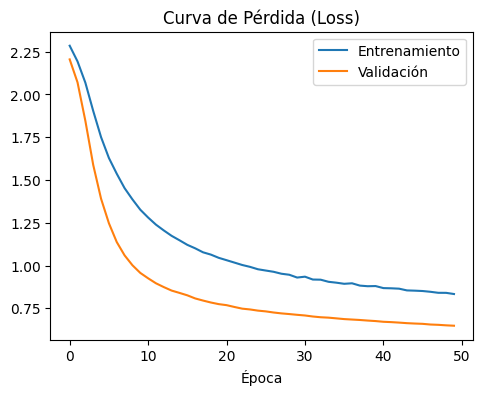

In [ ]:
# Plot 1: Pérdida (Loss)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_drop.history['loss'], label='Entrenamiento')
plt.plot(h_drop.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

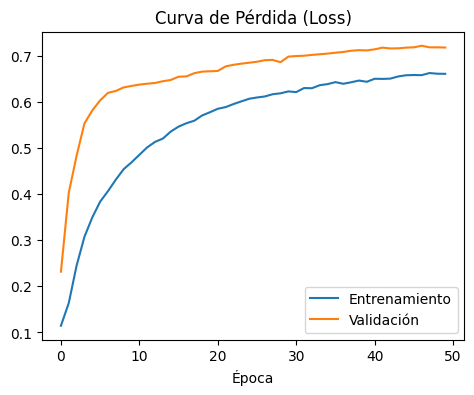

In [ ]:
# Plot 2: Accuracy (Precision)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h_drop.history['accuracy'], label='Entrenamiento')
plt.plot(h_drop.history['val_accuracy'], label='Validación')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.legend()

# Optimizador Adam

In [ ]:
# Reconstrucción de la Arquitectura aplicando Dropout
red_optimizada = keras.Sequential()

# Capa de entrada y Dropout inicial
red_optimizada.add(Dense(h1, input_dim = N, activation = 'relu', kernel_initializer = 'he_normal', name = 'primera_capa_opt'))
red_optimizada.add(Dropout(0.3))

# Capas ocultas con Dropout
red_optimizada.add(Dense(h2, activation = 'relu', name = 'segunda_capa_opt'))
red_optimizada.add(Dropout(0.2))

red_optimizada.add(Dense(h3, activation = 'relu', name = 'tercera_capa_opt'))
red_optimizada.add(Dropout(0.2))

red_optimizada.add(Dense(h4, activation = 'relu', name = 'cuarta_capa_opt'))
red_optimizada.add(Dropout(0.2))

# Capa de salida
red_optimizada.add(Dense(C, activation = 'softmax', name = 'capa_de_output_opt'))

# Compilación con Adam
opt_adam = Adam(learning_rate=0.001)

red_optimizada.compile(
    loss = 'categorical_crossentropy',
    optimizer = opt_adam,
    metrics = ['accuracy']
)

# Configuración de Early Stopping
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

# Entrenamiento
print("Iniciando entrenamiento optimizado...")
h_opt = red_optimizada.fit(
    X_train, Y_train,
    epochs = 50,
    batch_size = 32,
    validation_split = 0.2,
    callbacks = [early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento optimizado...
Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.6494 - loss: 0.9445 - val_accuracy: 0.8079 - val_loss: 0.5357
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7774 - loss: 0.6286 - val_accuracy: 0.8318 - val_loss: 0.4741
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8027 - loss: 0.5702 - val_accuracy: 0.8433 - val_loss: 0.4370
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8185 - loss: 0.5316 - val_accuracy: 0.8573 - val_loss: 0.3991
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8303 - loss: 0.5072 - val_accuracy: 0.8566 - val_loss: 0.3961
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8341 - loss: 0.4858 - val_accuracy: 0.8645 - val_loss: 0.3826
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8426 - loss: 0.4636 - val_accuracy: 0.8624 - val_loss: 0.3849
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/st

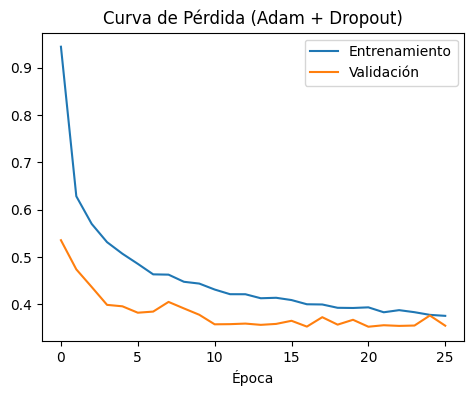

In [ ]:
# Gráficos de Rendimiento (Modelo Optimizado)
plt.figure(figsize = (12, 4))

# Plot 1: Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(h_opt.history['loss'], label = 'Entrenamiento')
plt.plot(h_opt.history['val_loss'], label = 'Validación')
plt.title('Curva de Pérdida (Adam + Dropout)')
plt.xlabel('Época')
plt.legend()

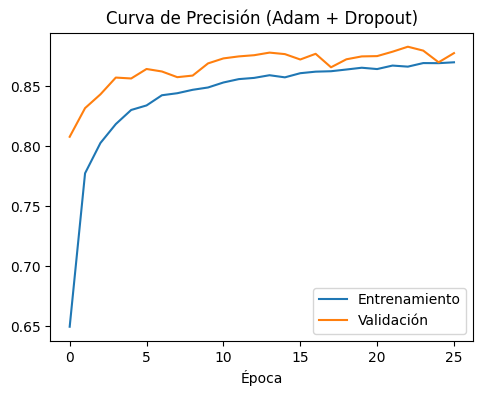

In [ ]:
plt.figure(figsize = (12, 4))
# Plot 2: Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(h_opt.history['accuracy'], label = 'Entrenamiento')
plt.plot(h_opt.history['val_accuracy'], label = 'Validación')
plt.title('Curva de Precisión (Adam + Dropout)')
plt.xlabel('Época')
plt.legend()
plt.show()


# Comparacion

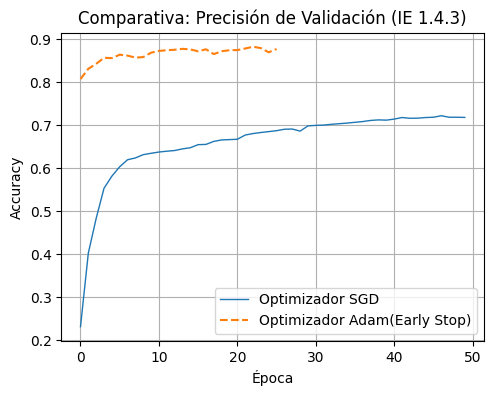

In [ ]:
plt.figure(figsize=(12, 4))

# --- Gráfico 1: Precisión de Validación (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(h_drop.history['val_accuracy'], label='Optimizador SGD', linewidth=1)
plt.plot(h_opt.history['val_accuracy'], label='Optimizador Adam(Early Stop)', linestyle='--')

plt.title('Comparativa: Precisión de Validación (IE 1.4.3)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

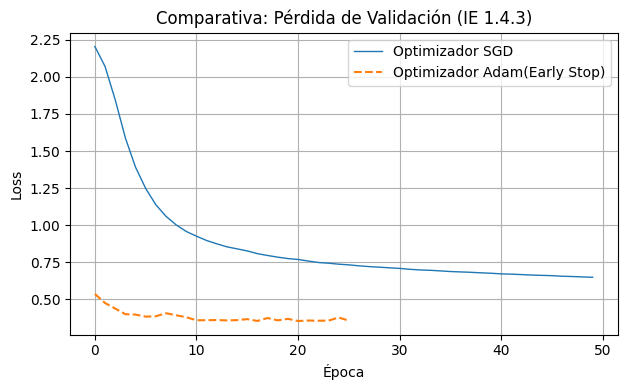

In [ ]:
plt.figure(figsize=(12, 4))
# --- Gráfico 2: Pérdida de Validación (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(h_drop.history['val_loss'], label='Optimizador SGD', linewidth=1)
plt.plot(h_opt.history['val_loss'], label='Optimizador Adam(Early Stop)', linestyle='--')

plt.title('Comparativa: Pérdida de Validación (IE 1.4.3)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 6.1 Comparativa de Desempeño: SGD vs. Adam (IE 1.4.3)

Tras contrastar ambos entrenamientos en esta fase de optimización, los resultados demuestran la superioridad técnica del optimizador adaptativo frente al estático cuando se integra regularización:

* **Optimizador SGD con Dropout (h_drop):**
    * **Rendimiento limitado:** Se observa que al SGD le cuesta recuperarse de la pérdida de información que genera el Dropout. La precisión de validación se estanca en un **71.87%**, lo que indica que con un *learning rate* estático y 50 épocas, la red no logra compensar la desactivación aleatoria de neuronas para encontrar patrones complejos.
    * **Convergencia lenta:** La curva muestra un aprendizaje mucho más pesado y con mayor dificultad para minimizar el error, finalizando con una pérdida de validación (**val_loss**) de **0.6480**, casi el doble que el modelo optimizado.

* **Optimizador Adam con Early Stopping (h_opt):**
    * **Convergencia acelerada:** Gracias a su tasa de aprendizaje adaptativa, Adam logra un **87.77%** de precisión en validación. Esto demuestra que Adam es mucho más robusto para trabajar con capas de **Dropout**, ya que ajusta los pesos de forma inteligente compensando el "ruido" introducido por la regularización.
    * **Optimización y Generalización:** El uso de **Early Stopping** permitió que el modelo se detuviera en el punto exacto de mejor rendimiento. Con un **val_loss de 0.3551**, este modelo no solo es más preciso, sino que está mejor generalizado para reconocer las prendas del dataset Fashion-MNIST sin memorizar los datos (evitando el Overfitting).

**Conclusión:** La combinación de **Adam + Dropout + Early Stopping** constituye la configuración más sólida, logrando un equilibrio entre una alta precisión y una excelente estabilidad en la validación.

### 6.2 Comparativa de Pérdida (Loss): SGD vs. Adam

El análisis de las curvas de pérdida nos permite entender cómo el optimizador gestiona el error y la capacidad de aprendizaje de la red bajo condiciones de regularización:

* **Optimizador SGD con Dropout (h_drop):**
    * **Descenso ineficiente:** A diferencia de las pruebas sin regularización, aquí el SGD muestra un descenso muy pobre, finalizando con un **val_loss de 0.6480**. Esto confirma que el optimizador estático no tiene la "fuerza" necesaria para encontrar el camino hacia el mínimo global cuando el Dropout está activo.
    * **Efecto del Dropout:** Se observa que la pérdida de validación es menor que la de entrenamiento (**0.6480 vs 0.8334**). Este es un síntoma positivo de generalización: durante el entrenamiento, el modelo trabaja con un 30% menos de neuronas, lo que eleva el error; pero en la validación, al usar el 100% de su capacidad, demuestra que no ha memorizado los datos.

* **Optimizador Adam con Early Stopping (h_opt):**
    * **Caída drástica y adaptativa:** La pérdida en validación se desploma velozmente hasta alcanzar un valor de **0.3551**. Adam ajusta el gradiente individualmente para cada peso, permitiendo que la red aprenda rasgos útiles incluso con la presencia de Dropout.
    * **El punto de corte óptimo:** Gracias al **Early Stopping**, el entrenamiento se detuvo en el momento exacto en que la pérdida de validación dejó de mejorar. Esto evitó que el modelo entrara en la zona de sobreajuste (Overfitting), donde la pérdida de entrenamiento sigue bajando pero la de validación empieza a subir, garantizando así el modelo más robusto posible.

**Diagnóstico Final:** Mientras que el SGD se quedó "atrapado" en una pérdida alta debido a la dificultad de aprender con ruido, **Adam** logró navegar la complejidad del dataset Fashion-MNIST, reduciendo el error casi a la mitad y logrando una sintonía fina de los pesos.

# Generacion de Resumen de Métricas


In [ ]:
# Generar predicciones para red_drop
y_pred_drop = red_drop.predict(X_test)
y_pred_classes_drop = np.argmax(y_pred_drop, axis = 1)
y_true_drop = np.argmax(Y_test, axis = 1)

print("\nInforme de Clasificación (Modelo SGD + Dropout)\n")
print(classification_report(y_true_drop, y_pred_classes_drop, target_names = class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Informe de Clasificación (Modelo SGD + Dropout)

              precision    recall  f1-score   support

 T-shirt/top       0.72      0.85      0.78      1000
     Trouser       0.98      0.95      0.97      1000
    Pullover       0.27      0.05      0.08      1000
       Dress       0.80      0.87      0.83      1000
        Coat       0.38      0.87      0.53      1000
      Sandal       0.85      0.78      0.82      1000
       Shirt       0.30      0.08      0.12      1000
     Sneaker       0.84      0.86      0.85      1000
         Bag       0.92      0.96      0.94      1000
  Ankle boot       0.88      0.94      0.91      1000

    accuracy                           0.72     10000
   macro avg       0.69      0.72      0.68     10000
weighted avg       0.69      0.72      0.68     10000



In [ ]:
# Cuadro Resumen de Métricas (Modelo Optimizado)
y_pred_opt = red_optimizada.predict(X_test)
y_pred_classes_opt = np.argmax(y_pred_opt, axis = 1)
y_true = np.argmax(Y_test, axis = 1)

print("\nInforme de Clasificación (Modelo Optimizado)\n")
print(classification_report(y_true, y_pred_classes_opt, target_names = class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Informe de Clasificación (Modelo Optimizado)

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.87      0.83      1000
     Trouser       1.00      0.95      0.97      1000
    Pullover       0.68      0.87      0.77      1000
       Dress       0.84      0.91      0.87      1000
        Coat       0.78      0.73      0.75      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.78      0.54      0.64      1000
     Sneaker       0.92      0.96      0.94      1000
         Bag       0.98      0.95      0.96      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



### 6.3 Conclusión de Clasificación (IE 1.4.1)

El análisis comparativo de las métricas por clase confirma que la optimización fue exitosa:

* **Recuperación de Clases:** El modelo **SGD** falló críticamente en prendas complejas como **Shirt (F1: 0.12)** y **Pullover (F1: 0.08)**. El modelo con **Adam** logró rescatar estas categorías subiendo su desempeño a **0.64** y **0.77** respectivamente.
* **Consistencia:** En categorías con formas claras (Trouser, Sandal, Bag), el modelo optimizado es casi perfecto, con un **F1-Score de 0.96-0.97**.
* **Balance Global:** El salto en el **F1-Score promedio (de 0.68 a 0.87)** demuestra que la combinación de Adam, Dropout y Early Stopping no solo mejoró la precisión, sino que hizo al modelo mucho más equilibrado y robusto frente a la ambigüedad visual.

# Matriz de Confusión

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


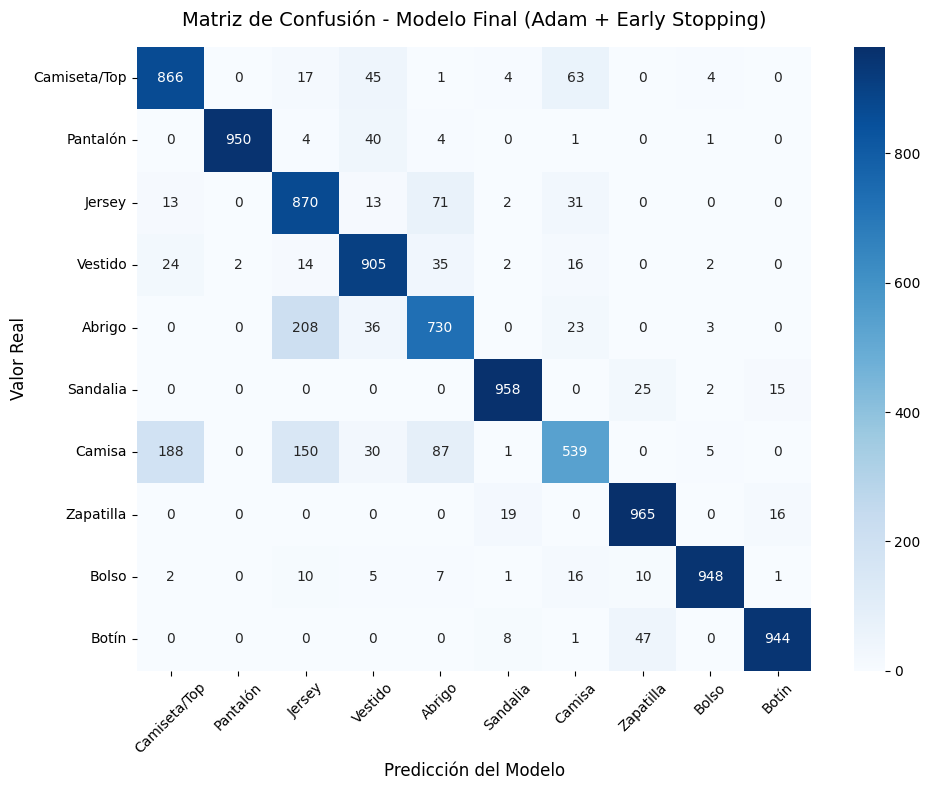

In [ ]:
# 1. Generar predicciones
y_pred_prob = red_optimizada.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# 1.5 ¡LA SOLUCIÓN! Convertir Y_test de formato one-hot a números enteros
Y_test_classes = np.argmax(Y_test, axis=1)

# 2. Definir los nombres reales de las clases
class_names = ['Camiseta/Top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

# 3. Calcular la matriz de confusión (Usando el nuevo Y_test_classes)
cm = confusion_matrix(Y_test_classes, y_pred_classes)

# 4. Graficar la matriz con Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

# Títulos y etiquetas
plt.title('Matriz de Confusión - Modelo Final (Adam + Early Stopping)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

# Mostrar el gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Conclusión Técnica

El desarrollo de este proyecto ha demostrado empíricamente la eficacia de las Redes Neuronales Artificiales (MLP) para abordar tareas complejas de visión computacional y clasificación de imágenes mediante el dataset Fashion-MNIST. A través de un enfoque analítico e iterativo, se comprobó que la definición de la topología de la red es solo el punto de partida, siendo la fase de ajuste de hiperparámetros y regularización el factor determinante para la viabilidad del modelo.

La transición desde una configuración base conservadora hacia una arquitectura dinámica generó mejoras sustanciales. El éxito técnico del modelo final se fundamenta en la integración de tres estrategias clave:

Regularización Espacial (Dropout): Forzó a la red a no depender de neuronas específicas, mitigando de forma efectiva el overfitting y promoviendo el aprendizaje de características generalizables de las prendas.

Optimización Adaptativa (Adam): Superó las limitaciones del gradiente descendente estocástico (SGD) estático, acelerando drásticamente la convergencia hacia el mínimo global de la función de pérdida.

Eficiencia Temporal (Early Stopping): Previno la degradación del modelo durante el entrenamiento prolongado, capturando el estado de los pesos exacto donde la capacidad de generalización era máxima.

Como resultado, el modelo final logró una exactitud (Accuracy) validada del 88% frente a datos completamente nuevos. Más allá de la métrica global, la red demostró una madurez analítica notable al incrementar el Recall y F1-Score en clases de alta similitud geométrica (como camisas frente a abrigos y camisetas).

Finalmente, la serialización exitosa del modelo entrenado confirma que el producto ha superado la etapa de validación de laboratorio y se encuentra empaquetado, optimizado y técnicamente preparado para su eventual despliegue en un entorno de producción.